# Replication Notebook

This notebook reproduces all main and robustness analyses reported in:

Christoph H. Maass (2025). Vaccination Intensity and Mortality During the COVID-19 Pandemic.

What this notebook does

The notebook implements a unified, configuration-driven pipeline for two outcomes:

- All-cause mortality (ACM)

- Non-COVID-19 mortality (NCM) (defined as ACM minus reported COVID-19 deaths)

Model families implemented

The notebook generates results for the following pre-specified model families:

A) Random-intercept (RI) models

- ACM — RI — RAW — full sample (89)

- NCM — RI — RAW — full sample (89)

- ACM — RI — RAW — STMF subsample (36)

- NCM — RI — RAW — STMF subsample (36)

- ACM — RI — WINSORIZED — full sample (89)

- NCM — RI — WINSORIZED — full sample (89)

B) Fixed-effects (FE) models (country FE)

- ACM — FE — RAW — full sample (89)

- NCM — FE — RAW — full sample (89)

How to run

Execute all cells sequentially from top to bottom to reproduce the reported results. The analysis is deterministic given the input dataset and configuration flags.

All data and code used in this notebook are publicly available, as described in the manuscript’s Data Availability section.

In [1]:
# =========================
# A) Random-intercept (RI) models
# =========================

Error importing in API mode: ImportError('On Windows, cffi mode "ANY" is only "ABI".')
Trying to import in ABI mode.


Countries: 89
Rows: 14863

=== Vaccination Intensity and All-Cause Mortality (ACM) — RI — RAW ===
                  Term Estimate    SE p-value
Vaccination lead (t+2)   +2.012 0.941   0.033
Vaccination lead (t+4)   +0.917 0.941   0.330
 Vaccination lag (t−2)   +2.005 0.941   0.033
 Vaccination lag (t−4)   -1.376 0.953   0.149
 Vaccination lag (t−6)   -1.880 0.955   0.049
 Vaccination lag (t−8)   -1.345 0.956   0.159
 Lag 6 × calendar time   -0.072 0.042   0.088
 Lag 8 × calendar time   -0.012 0.042   0.771


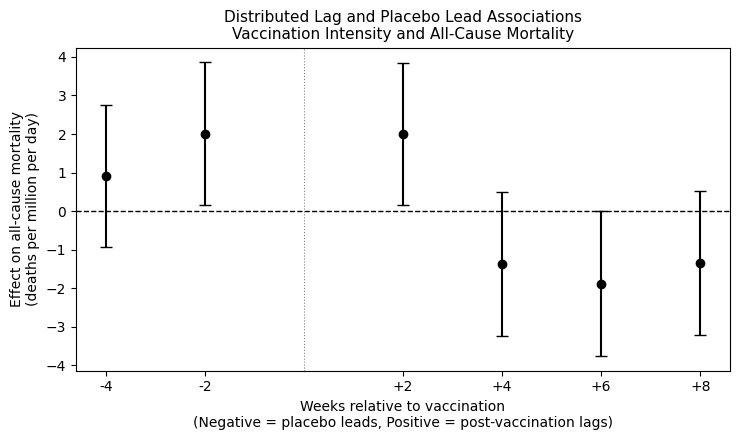

In [2]:
# =========================
# ACM — RI — RAW — full sample (89)
# =========================

import pandas as pd
import numpy as np

import rpy2.robjects as ro
from rpy2.robjects.conversion import localconverter
from rpy2.robjects import pandas2ri
from rpy2.robjects.packages import importr

import matplotlib.pyplot as plt

# -------------------------
# 1. R package
# -------------------------
nlme = importr("nlme")

# -------------------------
# 2. Load data
# -------------------------
df = pd.read_csv(
    r"C:\Maass\cross_national_covid_19_risk_policy_dataset_v1_archived\cross_national_covid_19_risk_policy_dataset_v1.csv",
    parse_dates=["date"]
).sort_values(["country", "date"]).reset_index(drop=True)

# -------------------------
# 3. Time index and centering
# -------------------------
df["t"] = df.groupby("country").cumcount()
df["t_c"] = df["t"] - df.groupby("country")["t"].transform("mean")

# -------------------------
# 4. Vaccination lags & placebo leads
# -------------------------
LAGS  = [2, 4, 6, 8]
LEADS = [2, 4]

for k in LAGS:
    df[f"vax_lag{k}"] = df.groupby("country")[
        "covid_19_vaccine_doses_administered"
    ].shift(k)

for k in LEADS:
    df[f"vax_lead{k}"] = df.groupby("country")[
        "covid_19_vaccine_doses_administered"
    ].shift(-k)

# Lag × calendar time interactions
df["vax_lag6_x_tc"] = df["vax_lag6"] * df["t_c"]
df["vax_lag8_x_tc"] = df["vax_lag8"] * df["t_c"]

# -------------------------
# 5. Drop NAs (single analytic sample)
# -------------------------
MODEL_VARS = [
    "all_cause_mortality",
    "country",
    "t", "t_c",
    "vax_lead2", "vax_lead4",
    "vax_lag2", "vax_lag4", "vax_lag6", "vax_lag8",
    "vax_lag6_x_tc", "vax_lag8_x_tc",
    "covid_19_incidence_original",
    "covid_19_prevalence_original",
    "covid_19_policy_stringency",
    "covid_19_face_covering_policy",
    "covid_19_testing_tracing_policy",
    "covid_19_variant_delta",
    "covid_19_variant_omicron",
    "sine_seasonality",
    "cosine_seasonality",
    "temperature",
    "relative_humidity",
]

df_m = df.dropna(subset=MODEL_VARS).copy()

print("Countries:", df_m["country"].nunique())
print("Rows:", df_m.shape[0])

# -------------------------
# 6. Send data to R
# -------------------------
with localconverter(pandas2ri.converter):
    ro.globalenv["df_m"] = df_m

# -------------------------
# 7. MODEL: nlme::lme
# -------------------------
ro.r("""
suppressMessages(library(nlme))

df_m$country <- as.factor(df_m$country)

m_core <- nlme::lme(
  fixed = all_cause_mortality ~
    t_c +
    vax_lead2 + vax_lead4 +
    vax_lag2 + vax_lag4 + vax_lag6 + vax_lag8 +
    vax_lag6_x_tc + vax_lag8_x_tc +
    covid_19_incidence_original +
    covid_19_prevalence_original +
    covid_19_policy_stringency +
    covid_19_face_covering_policy +
    covid_19_testing_tracing_policy +
    covid_19_variant_delta +
    covid_19_variant_omicron +
    sine_seasonality + cosine_seasonality +
    temperature + relative_humidity,
  random = ~ 1 | country,
  correlation = corAR1(form = ~ t | country),
  data = df_m,
  method = "REML",
  control = nlme::lmeControl(
    opt = "optim",
    msMaxIter = 200,
    niterEM = 50
  )
)

tt <- as.data.frame(summary(m_core)$tTable)
tt$term <- rownames(tt)
rownames(tt) <- NULL
tt
""")

with localconverter(pandas2ri.converter):
    tt = ro.r("tt")

# -------------------------
# 8. Output table (vaccination terms only)
# -------------------------
TERM_MAP = {
    "vax_lead2": "Vaccination lead (t+2)",
    "vax_lead4": "Vaccination lead (t+4)",
    "vax_lag2":  "Vaccination lag (t−2)",
    "vax_lag4":  "Vaccination lag (t−4)",
    "vax_lag6":  "Vaccination lag (t−6)",
    "vax_lag8":  "Vaccination lag (t−8)",
    "vax_lag6_x_tc": "Lag 6 × calendar time",
    "vax_lag8_x_tc": "Lag 8 × calendar time",
}

tab = (
    tt[tt["term"].isin(TERM_MAP.keys())]
    .assign(
        Term=lambda d: d["term"].map(TERM_MAP),
        Estimate=lambda d: d["Value"].map(lambda x: f"{x:+.3f}"),
        SE=lambda d: d["Std.Error"].map(lambda x: f"{x:.3f}"),
        **{"p-value": lambda d: d["p-value"].map(lambda x: f"{x:.3f}")},
    )
    [["Term", "Estimate", "SE", "p-value"]]
)

print("\n=== Vaccination Intensity and All-Cause Mortality (ACM) — RI — RAW ===")
print(tab.to_string(index=False))

# -------------------------
# 9. Figure: Distributed lag + placebo leads
# -------------------------
term_to_time = {
    "vax_lead4":  -4,
    "vax_lead2":  -2,
    "vax_lag2":   +2,
    "vax_lag4":   +4,
    "vax_lag6":   +6,
    "vax_lag8":   +8,
}

df_plot = tt[tt["term"].isin(term_to_time.keys())].copy()
df_plot["time"] = df_plot["term"].map(term_to_time)
df_plot = df_plot.sort_values("time")

x  = df_plot["time"].to_numpy()
y  = df_plot["Value"].to_numpy()
se = df_plot["Std.Error"].to_numpy()

fig, ax = plt.subplots(figsize=(7.5, 4.5))

ax.errorbar(
    x, y,
    yerr=1.96 * se,
    fmt="o",
    color="black",
    ecolor="black",
    capsize=4
)

ax.axhline(0, linestyle="--", color="black", linewidth=1)
ax.axvline(0, linestyle=":", color="gray", linewidth=0.8)

ax.set_xlabel(
    "Weeks relative to vaccination\n"
    "(Negative = placebo leads, Positive = post-vaccination lags)"
)
ax.set_ylabel("Effect on all-cause mortality\n(deaths per million per day)")
ax.set_xticks(x)
ax.set_xticklabels([f"{t:+d}" for t in x])

ax.set_title(
    "Distributed Lag and Placebo Lead Associations\n"
    "Vaccination Intensity and All-Cause Mortality",
    fontsize=11
)

plt.tight_layout()

# -------------------------
# 10. Save Figure 1 to C:\Maass
# -------------------------
FIG_PATH = r"C:\Maass\Figure_1_ACM_Distributed_Lag_Placebo_Leads.png"

plt.savefig(
    FIG_PATH,
    dpi=300,
    bbox_inches="tight",
    facecolor="white"
)

plt.show()

Countries: 89
Rows: 14863

=== Vaccination Intensity and Non-COVID-19 Mortality (NCM) — RI — RAW ===
                  Term Estimate    SE p-value
Vaccination lead (t+2)   +0.543 1.206   0.653
Vaccination lead (t+4)   -3.127 1.206   0.010
 Vaccination lag (t−2)   -0.826 1.206   0.493
 Vaccination lag (t−4)   -0.371 1.221   0.761
 Vaccination lag (t−6)   +0.304 1.224   0.804
 Vaccination lag (t−8)   +0.585 1.225   0.633
 Lag 6 × calendar time   -0.056 0.054   0.297
 Lag 8 × calendar time   -0.001 0.054   0.987


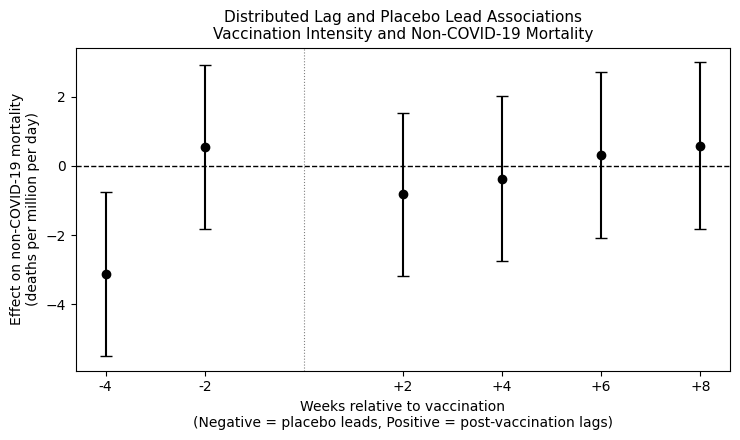

In [3]:
# =========================
# NCM — RI — RAW — full sample (89)
# =========================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

import rpy2.robjects as ro
from rpy2.robjects.conversion import localconverter
from rpy2.robjects import pandas2ri
from rpy2.robjects.packages import importr

# -------------------------
# 1. R package
# -------------------------
nlme = importr("nlme")

# -------------------------
# 2. Load data
# -------------------------
df = pd.read_csv(
    r"C:\Maass\cross_national_covid_19_risk_policy_dataset_v1_archived\cross_national_covid_19_risk_policy_dataset_v1.csv",
    parse_dates=["date"]
).sort_values(["country", "date"]).reset_index(drop=True)

# Construct non-COVID mortality (RAW)
df["non_covid_mortality"] = (
    df["all_cause_mortality"] - df["covid_19_mortality_original"]
)

# -------------------------
# 3. Time index + centered time
# -------------------------
df["t"] = df.groupby("country").cumcount()
df["t_c"] = df["t"] - df.groupby("country")["t"].transform("mean")

# -------------------------
# 4. Vaccination lags & placebo leads
# -------------------------
LAGS  = [2, 4, 6, 8]
LEADS = [2, 4]

for k in LAGS:
    df[f"vax_lag{k}"] = df.groupby("country")[
        "covid_19_vaccine_doses_administered"
    ].shift(k)

for k in LEADS:
    df[f"vax_lead{k}"] = df.groupby("country")[
        "covid_19_vaccine_doses_administered"
    ].shift(-k)

# Lag × calendar time interactions
df["vax_lag6_x_tc"] = df["vax_lag6"] * df["t_c"]
df["vax_lag8_x_tc"] = df["vax_lag8"] * df["t_c"]

# -------------------------
# 5. Drop NAs (single analytic sample)
# -------------------------
MODEL_VARS = [
    "non_covid_mortality",
    "country", "t", "t_c",
    "vax_lead2", "vax_lead4",
    "vax_lag2", "vax_lag4", "vax_lag6", "vax_lag8",
    "vax_lag6_x_tc", "vax_lag8_x_tc",
    "covid_19_incidence_original",
    "covid_19_prevalence_original",
    "covid_19_policy_stringency",
    "covid_19_face_covering_policy",
    "covid_19_testing_tracing_policy",
    "covid_19_variant_delta",
    "covid_19_variant_omicron",
    "sine_seasonality", "cosine_seasonality",
    "temperature", "relative_humidity",
]

df_m = df.dropna(subset=MODEL_VARS).copy()

print("Countries:", df_m["country"].nunique())
print("Rows:", df_m.shape[0])

# -------------------------
# 6. Send data to R
# -------------------------
with localconverter(pandas2ri.converter):
    ro.globalenv["df_m"] = df_m

# -------------------------
# 7. MODEL: nlme::lme (RI + AR1)
# -------------------------
ro.r("""
suppressMessages(library(nlme))

df_m$country <- as.factor(df_m$country)

m_core_ncm <- nlme::lme(
  fixed = non_covid_mortality ~
    t_c +
    vax_lead2 + vax_lead4 +
    vax_lag2 + vax_lag4 + vax_lag6 + vax_lag8 +
    vax_lag6_x_tc + vax_lag8_x_tc +
    covid_19_incidence_original +
    covid_19_prevalence_original +
    covid_19_policy_stringency +
    covid_19_face_covering_policy +
    covid_19_testing_tracing_policy +
    covid_19_variant_delta +
    covid_19_variant_omicron +
    sine_seasonality + cosine_seasonality +
    temperature + relative_humidity,
  random = ~ 1 | country,
  correlation = corAR1(form = ~ t | country),
  data = df_m,
  method = "REML",
  control = nlme::lmeControl(
    opt = "optim",
    msMaxIter = 200,
    niterEM = 50
  )
)

tt <- as.data.frame(summary(m_core_ncm)$tTable)
tt$term <- rownames(tt)
rownames(tt) <- NULL
tt
""")

with localconverter(pandas2ri.converter):
    tt = ro.r("tt")

# -------------------------
# 8. Output table (vaccination terms only)
# -------------------------
TERM_MAP = {
    "vax_lead2": "Vaccination lead (t+2)",
    "vax_lead4": "Vaccination lead (t+4)",
    "vax_lag2":  "Vaccination lag (t−2)",
    "vax_lag4":  "Vaccination lag (t−4)",
    "vax_lag6":  "Vaccination lag (t−6)",
    "vax_lag8":  "Vaccination lag (t−8)",
    "vax_lag6_x_tc": "Lag 6 × calendar time",
    "vax_lag8_x_tc": "Lag 8 × calendar time",
}

tab = (
    tt[tt["term"].isin(TERM_MAP.keys())]
    .assign(
        Term=lambda d: d["term"].map(TERM_MAP),
        Estimate=lambda d: d["Value"].map(lambda x: f"{x:+.3f}"),
        SE=lambda d: d["Std.Error"].map(lambda x: f"{x:.3f}"),
        **{"p-value": lambda d: d["p-value"].map(lambda x: f"{x:.3f}")},
    )
    [["Term", "Estimate", "SE", "p-value"]]
)

print("\n=== Vaccination Intensity and Non-COVID-19 Mortality (NCM) — RI — RAW ===")
print(tab.to_string(index=False))

# -------------------------
# 9. Distributed lag plot (NCM)
# -------------------------
term_to_time = {
    "vax_lead4":  -4,
    "vax_lead2":  -2,
    "vax_lag2":   +2,
    "vax_lag4":   +4,
    "vax_lag6":   +6,
    "vax_lag8":   +8,
}

df_plot = tt[tt["term"].isin(term_to_time.keys())].copy()
df_plot["time"] = df_plot["term"].map(term_to_time)
df_plot = df_plot.sort_values("time")

x  = df_plot["time"].to_numpy()
y  = df_plot["Value"].to_numpy()
se = df_plot["Std.Error"].to_numpy()

fig, ax = plt.subplots(figsize=(7.5, 4.5))

ax.errorbar(
    x, y,
    yerr=1.96 * se,
    fmt="o",
    color="black",
    ecolor="black",
    capsize=4
)

ax.axhline(0, linestyle="--", color="black", linewidth=1)
ax.axvline(0, linestyle=":", color="gray", linewidth=0.8)

ax.set_xlabel(
    "Weeks relative to vaccination\n"
    "(Negative = placebo leads, Positive = post-vaccination lags)"
)
ax.set_ylabel("Effect on non-COVID-19 mortality\n(deaths per million per day)")

ax.set_xticks(x)
ax.set_xticklabels([f"{t:+d}" for t in x])

ax.set_title(
    "Distributed Lag and Placebo Lead Associations\n"
    "Vaccination Intensity and Non-COVID-19 Mortality",
    fontsize=11
)

plt.tight_layout()
plt.show()

Countries: 36
Rows: 6012

=== Vaccination Intensity and All-Cause Mortality (ACM) — RI — RAW — STMF ===
                  Term Estimate    SE p-value
Vaccination lead (t+2)   +7.183 2.792   0.010
Vaccination lead (t+4)   +0.901 2.794   0.747
 Vaccination lag (t−2)   -3.662 2.789   0.189
 Vaccination lag (t−4)   -3.912 2.834   0.167
 Vaccination lag (t−6)   -7.991 2.834   0.005
 Vaccination lag (t−8)   -5.249 2.803   0.061
 Lag 6 × calendar time   -0.329 0.140   0.019
 Lag 8 × calendar time   -0.104 0.140   0.459


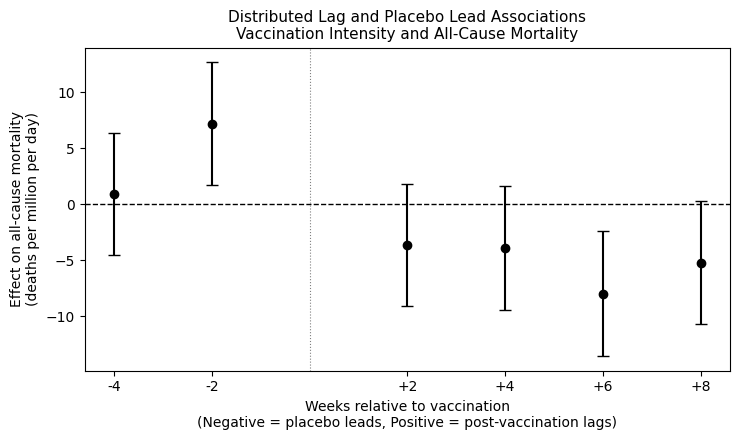

In [4]:
# =========================
# ACM — RI — RAW — STMF subsample (36)
# =========================

import pandas as pd
import numpy as np

import rpy2.robjects as ro
from rpy2.robjects.conversion import localconverter
from rpy2.robjects import pandas2ri
from rpy2.robjects.packages import importr

import matplotlib.pyplot as plt

# -------------------------
# 1. R package
# -------------------------
nlme = importr("nlme")

# -------------------------
# 2. Load data
# -------------------------
df = pd.read_csv(
    r"C:\Maass\cross_national_covid_19_risk_policy_dataset_v1_archived\cross_national_covid_19_risk_policy_dataset_v1.csv",
    parse_dates=["date"]
).sort_values(["country", "date"]).reset_index(drop=True)

# -------------------------
# 3. STMF restriction
# -------------------------
USE_STMF_SAMPLE = True

STMF_COUNTRIES = [
    "AUS","AUT","BEL","BGR","CAN","CHE","CHL","CZE","DEU","DNK",
    "ESP","EST","FIN","FRA","GBR","GRC","HRV","HUN","ISL","ISR",
    "ITA","KOR","LTU","LUX","LVA","NLD","NOR","NZL","POL","PRT",
    "RUS","SVK","SVN","SWE","TWN","USA"
]

if USE_STMF_SAMPLE:
    df = df[df["country_iso3"].isin(STMF_COUNTRIES)].copy()

# -------------------------
# 4. Time index and centering
# -------------------------
df["t"] = df.groupby("country").cumcount()
df["t_c"] = df["t"] - df.groupby("country")["t"].transform("mean")

# -------------------------
# 5. Vaccination lags & placebo leads
# -------------------------
LAGS  = [2, 4, 6, 8]
LEADS = [2, 4]

for k in LAGS:
    df[f"vax_lag{k}"] = df.groupby("country")[
        "covid_19_vaccine_doses_administered"
    ].shift(k)

for k in LEADS:
    df[f"vax_lead{k}"] = df.groupby("country")[
        "covid_19_vaccine_doses_administered"
    ].shift(-k)

# Lag × calendar time interactions
df["vax_lag6_x_tc"] = df["vax_lag6"] * df["t_c"]
df["vax_lag8_x_tc"] = df["vax_lag8"] * df["t_c"]

# -------------------------
# 6. Drop NAs (single analytic sample)
# -------------------------
MODEL_VARS = [
    "all_cause_mortality",
    "country",
    "t", "t_c",
    "vax_lead2", "vax_lead4",
    "vax_lag2", "vax_lag4", "vax_lag6", "vax_lag8",
    "vax_lag6_x_tc", "vax_lag8_x_tc",
    "covid_19_incidence_original",
    "covid_19_prevalence_original",
    "covid_19_policy_stringency",
    "covid_19_face_covering_policy",
    "covid_19_testing_tracing_policy",
    "covid_19_variant_delta",
    "covid_19_variant_omicron",
    "sine_seasonality",
    "cosine_seasonality",
    "temperature",
    "relative_humidity",
]

df_m = df.dropna(subset=MODEL_VARS).copy()

print("Countries:", df_m["country"].nunique())
print("Rows:", df_m.shape[0])

# -------------------------
# 7. Send data to R
# -------------------------
with localconverter(pandas2ri.converter):
    ro.globalenv["df_m"] = df_m

# -------------------------
# 8. MODEL: nlme::lme
# -------------------------
ro.r("""
suppressMessages(library(nlme))

df_m$country <- as.factor(df_m$country)

m_core <- nlme::lme(
  fixed = all_cause_mortality ~
    t_c +
    vax_lead2 + vax_lead4 +
    vax_lag2 + vax_lag4 + vax_lag6 + vax_lag8 +
    vax_lag6_x_tc + vax_lag8_x_tc +
    covid_19_incidence_original +
    covid_19_prevalence_original +
    covid_19_policy_stringency +
    covid_19_face_covering_policy +
    covid_19_testing_tracing_policy +
    covid_19_variant_delta +
    covid_19_variant_omicron +
    sine_seasonality + cosine_seasonality +
    temperature + relative_humidity,
  random = ~ 1 | country,
  correlation = corAR1(form = ~ t | country),
  data = df_m,
  method = "REML",
  control = nlme::lmeControl(
    opt = "optim",
    msMaxIter = 200,
    niterEM = 50
  )
)

tt <- as.data.frame(summary(m_core)$tTable)
tt$term <- rownames(tt)
rownames(tt) <- NULL
tt
""")

with localconverter(pandas2ri.converter):
    tt = ro.r("tt")

# -------------------------
# 9. Output table (vaccination terms only)
# -------------------------
TERM_MAP = {
    "vax_lead2": "Vaccination lead (t+2)",
    "vax_lead4": "Vaccination lead (t+4)",
    "vax_lag2":  "Vaccination lag (t−2)",
    "vax_lag4":  "Vaccination lag (t−4)",
    "vax_lag6":  "Vaccination lag (t−6)",
    "vax_lag8":  "Vaccination lag (t−8)",
    "vax_lag6_x_tc": "Lag 6 × calendar time",
    "vax_lag8_x_tc": "Lag 8 × calendar time",
}

tab = (
    tt[tt["term"].isin(TERM_MAP.keys())]
    .assign(
        Term=lambda d: d["term"].map(TERM_MAP),
        Estimate=lambda d: d["Value"].map(lambda x: f"{x:+.3f}"),
        SE=lambda d: d["Std.Error"].map(lambda x: f"{x:.3f}"),
        **{"p-value": lambda d: d["p-value"].map(lambda x: f"{x:.3f}")},
    )
    [["Term", "Estimate", "SE", "p-value"]]
)

print("\n=== Vaccination Intensity and All-Cause Mortality (ACM) — RI — RAW — STMF ===")
print(tab.to_string(index=False))

# -------------------------
# 10. Figure: Distributed lag + placebo leads
# -------------------------
term_to_time = {
    "vax_lead4":  -4,
    "vax_lead2":  -2,
    "vax_lag2":   +2,
    "vax_lag4":   +4,
    "vax_lag6":   +6,
    "vax_lag8":   +8,
}

df_plot = tt[tt["term"].isin(term_to_time.keys())].copy()
df_plot["time"] = df_plot["term"].map(term_to_time)
df_plot = df_plot.sort_values("time")

x  = df_plot["time"].to_numpy()
y  = df_plot["Value"].to_numpy()
se = df_plot["Std.Error"].to_numpy()

fig, ax = plt.subplots(figsize=(7.5, 4.5))

ax.errorbar(
    x, y,
    yerr=1.96 * se,
    fmt="o",
    color="black",
    ecolor="black",
    capsize=4
)

ax.axhline(0, linestyle="--", color="black", linewidth=1)
ax.axvline(0, linestyle=":", color="gray", linewidth=0.8)

ax.set_xlabel(
    "Weeks relative to vaccination\n"
    "(Negative = placebo leads, Positive = post-vaccination lags)"
)
ax.set_ylabel("Effect on all-cause mortality\n(deaths per million per day)")
ax.set_xticks(x)
ax.set_xticklabels([f"{t:+d}" for t in x])

ax.set_title(
    "Distributed Lag and Placebo Lead Associations\n"
    "Vaccination Intensity and All-Cause Mortality",
    fontsize=11
)

plt.tight_layout()
plt.show()


Countries: 36
Rows: 6012

=== Vaccination Intensity and Non-COVID-19 Mortality (NCM) — RI — RAW — STMF ===
                  Term Estimate    SE p-value
Vaccination lead (t+2)   +0.665 2.848   0.815
Vaccination lead (t+4)   -1.803 2.849   0.527
 Vaccination lag (t−2)   -1.159 2.846   0.684
 Vaccination lag (t−4)   -0.686 2.889   0.812
 Vaccination lag (t−6)   +1.081 2.892   0.709
 Vaccination lag (t−8)   -0.728 2.859   0.799
 Lag 6 × calendar time   -0.067 0.143   0.639
 Lag 8 × calendar time   +0.114 0.143   0.425


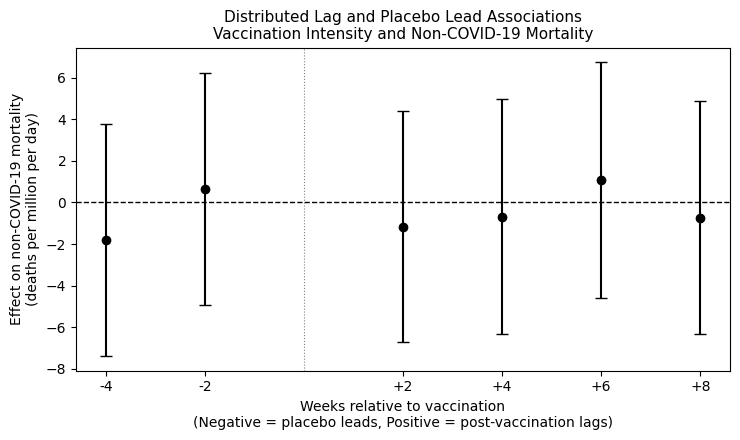

In [5]:
# =========================
# NCM — RI — RAW — STMF subsample (36)
# =========================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

import rpy2.robjects as ro
from rpy2.robjects.conversion import localconverter
from rpy2.robjects import pandas2ri
from rpy2.robjects.packages import importr

# -------------------------
# 1. R package
# -------------------------
nlme = importr("nlme")

# -------------------------
# 2. Load data
# -------------------------
df = pd.read_csv(
    r"C:\Maass\cross_national_covid_19_risk_policy_dataset_v1_archived\cross_national_covid_19_risk_policy_dataset_v1.csv",
    parse_dates=["date"]
).sort_values(["country", "date"]).reset_index(drop=True)

# Construct non-COVID mortality (RAW)
df["non_covid_mortality"] = (
    df["all_cause_mortality"] - df["covid_19_mortality_original"]
)

# -------------------------
# 3. STMF restriction
# -------------------------
USE_STMF_SAMPLE = True

STMF_COUNTRIES = [
    "AUS","AUT","BEL","BGR","CAN","CHE","CHL","CZE","DEU","DNK",
    "ESP","EST","FIN","FRA","GBR","GRC","HRV","HUN","ISL","ISR",
    "ITA","KOR","LTU","LUX","LVA","NLD","NOR","NZL","POL","PRT",
    "RUS","SVK","SVN","SWE","TWN","USA"
]

if USE_STMF_SAMPLE:
    df = df[df["country_iso3"].isin(STMF_COUNTRIES)].copy()

# -------------------------
# 4. Time index + centered time
# -------------------------
df["t"] = df.groupby("country").cumcount()
df["t_c"] = df["t"] - df.groupby("country")["t"].transform("mean")

# -------------------------
# 5. Vaccination lags & placebo leads
# -------------------------
LAGS  = [2, 4, 6, 8]
LEADS = [2, 4]

for k in LAGS:
    df[f"vax_lag{k}"] = df.groupby("country")[
        "covid_19_vaccine_doses_administered"
    ].shift(k)

for k in LEADS:
    df[f"vax_lead{k}"] = df.groupby("country")[
        "covid_19_vaccine_doses_administered"
    ].shift(-k)

# Lag × calendar time interactions
df["vax_lag6_x_tc"] = df["vax_lag6"] * df["t_c"]
df["vax_lag8_x_tc"] = df["vax_lag8"] * df["t_c"]

# -------------------------
# 6. Drop NAs (single analytic sample)
# -------------------------
MODEL_VARS = [
    "non_covid_mortality",
    "country", "t", "t_c",
    "vax_lead2", "vax_lead4",
    "vax_lag2", "vax_lag4", "vax_lag6", "vax_lag8",
    "vax_lag6_x_tc", "vax_lag8_x_tc",
    "covid_19_incidence_original",
    "covid_19_prevalence_original",
    "covid_19_policy_stringency",
    "covid_19_face_covering_policy",
    "covid_19_testing_tracing_policy",
    "covid_19_variant_delta",
    "covid_19_variant_omicron",
    "sine_seasonality", "cosine_seasonality",
    "temperature", "relative_humidity",
]

df_m = df.dropna(subset=MODEL_VARS).copy()

print("Countries:", df_m["country"].nunique())
print("Rows:", df_m.shape[0])

# -------------------------
# 7. Send data to R
# -------------------------
with localconverter(pandas2ri.converter):
    ro.globalenv["df_m"] = df_m

# -------------------------
# 8. MODEL: nlme::lme (RI + AR1)
# -------------------------
ro.r("""
suppressMessages(library(nlme))

df_m$country <- as.factor(df_m$country)

m_core_ncm <- nlme::lme(
  fixed = non_covid_mortality ~
    t_c +
    vax_lead2 + vax_lead4 +
    vax_lag2 + vax_lag4 + vax_lag6 + vax_lag8 +
    vax_lag6_x_tc + vax_lag8_x_tc +
    covid_19_incidence_original +
    covid_19_prevalence_original +
    covid_19_policy_stringency +
    covid_19_face_covering_policy +
    covid_19_testing_tracing_policy +
    covid_19_variant_delta +
    covid_19_variant_omicron +
    sine_seasonality + cosine_seasonality +
    temperature + relative_humidity,
  random = ~ 1 | country,
  correlation = corAR1(form = ~ t | country),
  data = df_m,
  method = "REML",
  control = nlme::lmeControl(
    opt = "optim",
    msMaxIter = 200,
    niterEM = 50
  )
)

tt <- as.data.frame(summary(m_core_ncm)$tTable)
tt$term <- rownames(tt)
rownames(tt) <- NULL
tt
""")

with localconverter(pandas2ri.converter):
    tt = ro.r("tt")

# -------------------------
# 9. Output table (vaccination terms only)
# -------------------------
TERM_MAP = {
    "vax_lead2": "Vaccination lead (t+2)",
    "vax_lead4": "Vaccination lead (t+4)",
    "vax_lag2":  "Vaccination lag (t−2)",
    "vax_lag4":  "Vaccination lag (t−4)",
    "vax_lag6":  "Vaccination lag (t−6)",
    "vax_lag8":  "Vaccination lag (t−8)",
    "vax_lag6_x_tc": "Lag 6 × calendar time",
    "vax_lag8_x_tc": "Lag 8 × calendar time",
}

tab = (
    tt[tt["term"].isin(TERM_MAP.keys())]
    .assign(
        Term=lambda d: d["term"].map(TERM_MAP),
        Estimate=lambda d: d["Value"].map(lambda x: f"{x:+.3f}"),
        SE=lambda d: d["Std.Error"].map(lambda x: f"{x:.3f}"),
        **{"p-value": lambda d: d["p-value"].map(lambda x: f"{x:.3f}")},
    )
    [["Term", "Estimate", "SE", "p-value"]]
)

print("\n=== Vaccination Intensity and Non-COVID-19 Mortality (NCM) — RI — RAW — STMF ===")
print(tab.to_string(index=False))

# -------------------------
# 10. Distributed lag plot (NCM)
# -------------------------
term_to_time = {
    "vax_lead4":  -4,
    "vax_lead2":  -2,
    "vax_lag2":   +2,
    "vax_lag4":   +4,
    "vax_lag6":   +6,
    "vax_lag8":   +8,
}

df_plot = tt[tt["term"].isin(term_to_time.keys())].copy()
df_plot["time"] = df_plot["term"].map(term_to_time)
df_plot = df_plot.sort_values("time")

x  = df_plot["time"].to_numpy()
y  = df_plot["Value"].to_numpy()
se = df_plot["Std.Error"].to_numpy()

fig, ax = plt.subplots(figsize=(7.5, 4.5))

ax.errorbar(
    x, y,
    yerr=1.96 * se,
    fmt="o",
    color="black",
    ecolor="black",
    capsize=4
)

ax.axhline(0, linestyle="--", color="black", linewidth=1)
ax.axvline(0, linestyle=":", color="gray", linewidth=0.8)

ax.set_xlabel(
    "Weeks relative to vaccination\n"
    "(Negative = placebo leads, Positive = post-vaccination lags)"
)
ax.set_ylabel("Effect on non-COVID-19 mortality\n(deaths per million per day)")

ax.set_xticks(x)
ax.set_xticklabels([f"{t:+d}" for t in x])

ax.set_title(
    "Distributed Lag and Placebo Lead Associations\n"
    "Vaccination Intensity and Non-COVID-19 Mortality",
    fontsize=11
)

plt.tight_layout()
plt.show()

Countries: 89
Rows: 14863

=== Vaccination Intensity and All-Cause Mortality (ACM) — RI — WINSORIZED ===
                  Term Estimate    SE p-value
Vaccination lead (t+2)   +2.018 0.920   0.028
Vaccination lead (t+4)   +1.062 0.920   0.248
 Vaccination lag (t−2)   +2.021 0.920   0.028
 Vaccination lag (t−4)   -1.241 0.931   0.183
 Vaccination lag (t−6)   -1.737 0.934   0.063
 Vaccination lag (t−8)   -1.184 0.934   0.205
 Lag 6 × calendar time   -0.067 0.041   0.104
 Lag 8 × calendar time   -0.010 0.041   0.808


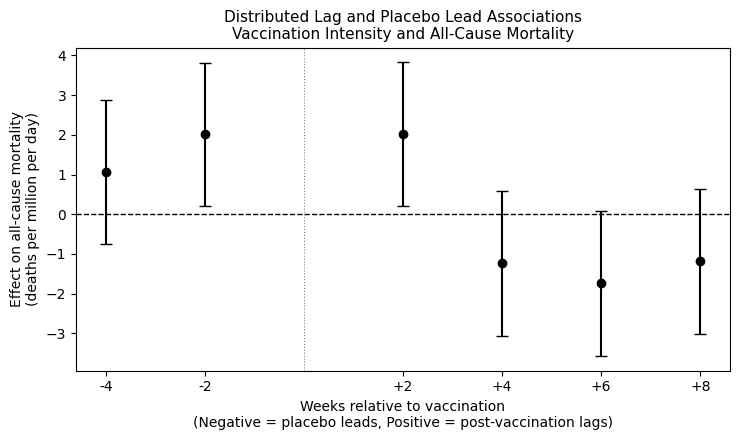

In [6]:
# =========================
# ACM — RI — Outlier control — full sample (89)
# =========================

import pandas as pd
import numpy as np

import rpy2.robjects as ro
from rpy2.robjects.conversion import localconverter
from rpy2.robjects import pandas2ri
from rpy2.robjects.packages import importr

import matplotlib.pyplot as plt

# -------------------------
# 1. R package
# -------------------------
nlme = importr("nlme")

# -------------------------
# 2. Load data
# -------------------------
df = pd.read_csv(
    r"C:\Maass\cross_national_covid_19_risk_policy_dataset_v1_archived\cross_national_covid_19_risk_policy_dataset_v1.csv",
    parse_dates=["date"]
).sort_values(["country", "date"]).reset_index(drop=True)

# -------------------------
# 2.1 Helper
# -------------------------
def winsorize_by_country(df, country_col, value_col, lo=0.01, hi=0.99):
    qs = (
        df.groupby(country_col)[value_col]
          .quantile([lo, hi])
          .unstack()
          .rename(columns={lo: "lo", hi: "hi"})
    )
    return df[value_col].clip(
        lower=df[country_col].map(qs["lo"]),
        upper=df[country_col].map(qs["hi"])
    )

# -------------------------
# 2.2 Preprocessing
# -------------------------
# Outcomes
df["all_cause_mortality"] = winsorize_by_country(
    df, "country", "all_cause_mortality", lo=0.01, hi=0.99
)
# Exposure
#df["covid_19_vaccine_doses_administered"] = winsorize_by_country(
    #df, "country", "covid_19_vaccine_doses_administered", lo=0.01, hi=0.99
#)

# -------------------------
# 3. Time index and centering
# -------------------------
df["t"] = df.groupby("country").cumcount()
df["t_c"] = df["t"] - df.groupby("country")["t"].transform("mean")

# -------------------------
# 4. Vaccination lags & placebo leads
# -------------------------
LAGS  = [2, 4, 6, 8]
LEADS = [2, 4]

for k in LAGS:
    df[f"vax_lag{k}"] = df.groupby("country")[
        "covid_19_vaccine_doses_administered"
    ].shift(k)

for k in LEADS:
    df[f"vax_lead{k}"] = df.groupby("country")[
        "covid_19_vaccine_doses_administered"
    ].shift(-k)

# Lag × calendar time interactions
df["vax_lag6_x_tc"] = df["vax_lag6"] * df["t_c"]
df["vax_lag8_x_tc"] = df["vax_lag8"] * df["t_c"]

# -------------------------
# 5. Drop NAs (single analytic sample)
# -------------------------
MODEL_VARS = [
    "all_cause_mortality",
    "country",
    "t", "t_c",
    "vax_lead2", "vax_lead4",
    "vax_lag2", "vax_lag4", "vax_lag6", "vax_lag8",
    "vax_lag6_x_tc", "vax_lag8_x_tc",
    "covid_19_incidence_original",
    "covid_19_prevalence_original",
    "covid_19_policy_stringency",
    "covid_19_face_covering_policy",
    "covid_19_testing_tracing_policy",
    "covid_19_variant_delta",
    "covid_19_variant_omicron",
    "sine_seasonality",
    "cosine_seasonality",
    "temperature",
    "relative_humidity",
]

df_m = df.dropna(subset=MODEL_VARS).copy()

print("Countries:", df_m["country"].nunique())
print("Rows:", df_m.shape[0])

# -------------------------
# 6. Send data to R
# -------------------------
with localconverter(pandas2ri.converter):
    ro.globalenv["df_m"] = df_m

# -------------------------
# 7. MODEL: nlme::lme
# -------------------------
ro.r("""
suppressMessages(library(nlme))

df_m$country <- as.factor(df_m$country)

m_core <- nlme::lme(
  fixed = all_cause_mortality ~
    t_c +
    vax_lead2 + vax_lead4 +
    vax_lag2 + vax_lag4 + vax_lag6 + vax_lag8 +
    vax_lag6_x_tc + vax_lag8_x_tc +
    covid_19_incidence_original +
    covid_19_prevalence_original +
    covid_19_policy_stringency +
    covid_19_face_covering_policy +
    covid_19_testing_tracing_policy +
    covid_19_variant_delta +
    covid_19_variant_omicron +
    sine_seasonality + cosine_seasonality +
    temperature + relative_humidity,
  random = ~ 1 | country,
  correlation = corAR1(form = ~ t | country),
  data = df_m,
  method = "REML",
  control = nlme::lmeControl(
    opt = "optim",
    msMaxIter = 200,
    niterEM = 50
  )
)

tt <- as.data.frame(summary(m_core)$tTable)
tt$term <- rownames(tt)
rownames(tt) <- NULL
tt
""")

with localconverter(pandas2ri.converter):
    tt = ro.r("tt")

# -------------------------
# 8. Output table (vaccination terms only)
# -------------------------
TERM_MAP = {
    "vax_lead2": "Vaccination lead (t+2)",
    "vax_lead4": "Vaccination lead (t+4)",
    "vax_lag2":  "Vaccination lag (t−2)",
    "vax_lag4":  "Vaccination lag (t−4)",
    "vax_lag6":  "Vaccination lag (t−6)",
    "vax_lag8":  "Vaccination lag (t−8)",
    "vax_lag6_x_tc": "Lag 6 × calendar time",
    "vax_lag8_x_tc": "Lag 8 × calendar time",
}

tab = (
    tt[tt["term"].isin(TERM_MAP.keys())]
    .assign(
        Term=lambda d: d["term"].map(TERM_MAP),
        Estimate=lambda d: d["Value"].map(lambda x: f"{x:+.3f}"),
        SE=lambda d: d["Std.Error"].map(lambda x: f"{x:.3f}"),
        **{"p-value": lambda d: d["p-value"].map(lambda x: f"{x:.3f}")},
    )
    [["Term", "Estimate", "SE", "p-value"]]
)

print("\n=== Vaccination Intensity and All-Cause Mortality (ACM) — RI — WINSORIZED ===")
print(tab.to_string(index=False))

# -------------------------
# 9. Figure: Distributed lag + placebo leads
# -------------------------
term_to_time = {
    "vax_lead4":  -4,
    "vax_lead2":  -2,
    "vax_lag2":   +2,
    "vax_lag4":   +4,
    "vax_lag6":   +6,
    "vax_lag8":   +8,
}

df_plot = tt[tt["term"].isin(term_to_time.keys())].copy()
df_plot["time"] = df_plot["term"].map(term_to_time)
df_plot = df_plot.sort_values("time")

x  = df_plot["time"].to_numpy()
y  = df_plot["Value"].to_numpy()
se = df_plot["Std.Error"].to_numpy()

fig, ax = plt.subplots(figsize=(7.5, 4.5))

ax.errorbar(
    x, y,
    yerr=1.96 * se,
    fmt="o",
    color="black",
    ecolor="black",
    capsize=4
)

ax.axhline(0, linestyle="--", color="black", linewidth=1)
ax.axvline(0, linestyle=":", color="gray", linewidth=0.8)

ax.set_xlabel(
    "Weeks relative to vaccination\n"
    "(Negative = placebo leads, Positive = post-vaccination lags)"
)
ax.set_ylabel("Effect on all-cause mortality\n(deaths per million per day)")
ax.set_xticks(x)
ax.set_xticklabels([f"{t:+d}" for t in x])

ax.set_title(
    "Distributed Lag and Placebo Lead Associations\n"
    "Vaccination Intensity and All-Cause Mortality",
    fontsize=11
)

plt.tight_layout()
plt.show()


Countries: 89
Rows: 14863

=== Vaccination Intensity and Non-COVID-19 Mortality (NCM) — RI — WINSORIZED ===
                  Term Estimate    SE p-value
Vaccination lead (t+2)   +0.495 0.982   0.615
Vaccination lead (t+4)   -1.188 0.982   0.227
 Vaccination lag (t−2)   -1.083 0.982   0.270
 Vaccination lag (t−4)   -0.732 0.995   0.462
 Vaccination lag (t−6)   +0.137 0.997   0.891
 Vaccination lag (t−8)   +0.154 0.998   0.877
 Lag 6 × calendar time   -0.046 0.044   0.295
 Lag 8 × calendar time   +0.017 0.044   0.696


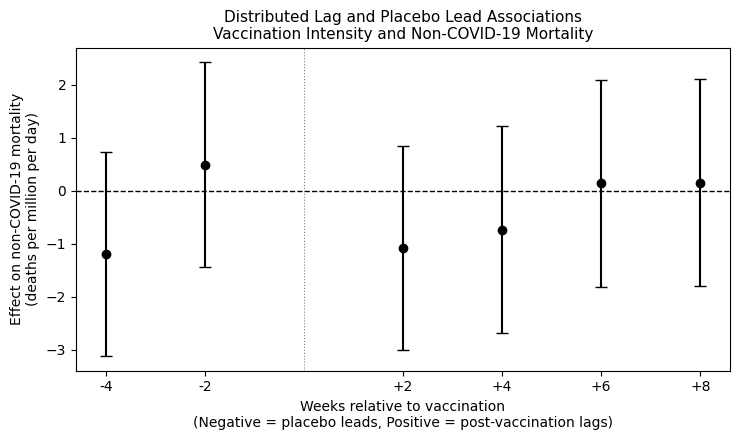

In [7]:
# =========================
# NCM — RI — Outlier control — full sample (89)
# =========================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

import rpy2.robjects as ro
from rpy2.robjects.conversion import localconverter
from rpy2.robjects import pandas2ri
from rpy2.robjects.packages import importr

# -------------------------
# 1. R package
# -------------------------
nlme = importr("nlme")

# -------------------------
# 2. Load data
# -------------------------
df = pd.read_csv(
    r"C:\Maass\cross_national_covid_19_risk_policy_dataset_v1_archived\cross_national_covid_19_risk_policy_dataset_v1.csv",
    parse_dates=["date"]
).sort_values(["country", "date"]).reset_index(drop=True)

# Construct non-COVID mortality (RAW)
df["non_covid_mortality"] = (
    df["all_cause_mortality"] - df["covid_19_mortality_original"]
)

# -------------------------
# 2.1 Helper
# -------------------------
def winsorize_by_country(df, country_col, value_col, lo=0.01, hi=0.99):
    qs = (
        df.groupby(country_col)[value_col]
          .quantile([lo, hi])
          .unstack()
          .rename(columns={lo: "lo", hi: "hi"})
    )
    return df[value_col].clip(
        lower=df[country_col].map(qs["lo"]),
        upper=df[country_col].map(qs["hi"])
    )

# -------------------------
# 2.2 Preprocessing
# -------------------------
# Outcomes
df["non_covid_mortality"] = winsorize_by_country(
    df, "country", "non_covid_mortality", lo=0.01, hi=0.99
)
# Exposure
#df["covid_19_vaccine_doses_administered"] = winsorize_by_country(
    #df, "country", "covid_19_vaccine_doses_administered", lo=0.01, hi=0.99
#)

# -------------------------
# 3. Time index + centered time
# -------------------------
df["t"] = df.groupby("country").cumcount()
df["t_c"] = df["t"] - df.groupby("country")["t"].transform("mean")

# -------------------------
# 4. Vaccination lags & placebo leads
# -------------------------
LAGS  = [2, 4, 6, 8]
LEADS = [2, 4]

for k in LAGS:
    df[f"vax_lag{k}"] = df.groupby("country")[
        "covid_19_vaccine_doses_administered"
    ].shift(k)

for k in LEADS:
    df[f"vax_lead{k}"] = df.groupby("country")[
        "covid_19_vaccine_doses_administered"
    ].shift(-k)

# Lag × calendar time interactions
df["vax_lag6_x_tc"] = df["vax_lag6"] * df["t_c"]
df["vax_lag8_x_tc"] = df["vax_lag8"] * df["t_c"]

# -------------------------
# 5. Drop NAs (single analytic sample)
# -------------------------
MODEL_VARS = [
    "non_covid_mortality",
    "country", "t", "t_c",
    "vax_lead2", "vax_lead4",
    "vax_lag2", "vax_lag4", "vax_lag6", "vax_lag8",
    "vax_lag6_x_tc", "vax_lag8_x_tc",
    "covid_19_incidence_original",
    "covid_19_prevalence_original",
    "covid_19_policy_stringency",
    "covid_19_face_covering_policy",
    "covid_19_testing_tracing_policy",
    "covid_19_variant_delta",
    "covid_19_variant_omicron",
    "sine_seasonality", "cosine_seasonality",
    "temperature", "relative_humidity",
]

df_m = df.dropna(subset=MODEL_VARS).copy()

print("Countries:", df_m["country"].nunique())
print("Rows:", df_m.shape[0])

# -------------------------
# 6. Send data to R
# -------------------------
with localconverter(pandas2ri.converter):
    ro.globalenv["df_m"] = df_m

# -------------------------
# 7. MODEL: nlme::lme (RI + AR1)
# -------------------------
ro.r("""
suppressMessages(library(nlme))

df_m$country <- as.factor(df_m$country)

m_core_ncm <- nlme::lme(
  fixed = non_covid_mortality ~
    t_c +
    vax_lead2 + vax_lead4 +
    vax_lag2 + vax_lag4 + vax_lag6 + vax_lag8 +
    vax_lag6_x_tc + vax_lag8_x_tc +
    covid_19_incidence_original +
    covid_19_prevalence_original +
    covid_19_policy_stringency +
    covid_19_face_covering_policy +
    covid_19_testing_tracing_policy +
    covid_19_variant_delta +
    covid_19_variant_omicron +
    sine_seasonality + cosine_seasonality +
    temperature + relative_humidity,
  random = ~ 1 | country,
  correlation = corAR1(form = ~ t | country),
  data = df_m,
  method = "REML",
  control = nlme::lmeControl(
    opt = "optim",
    msMaxIter = 200,
    niterEM = 50
  )
)

tt <- as.data.frame(summary(m_core_ncm)$tTable)
tt$term <- rownames(tt)
rownames(tt) <- NULL
tt
""")

with localconverter(pandas2ri.converter):
    tt = ro.r("tt")

# -------------------------
# 8. Output table (vaccination terms only)
# -------------------------
TERM_MAP = {
    "vax_lead2": "Vaccination lead (t+2)",
    "vax_lead4": "Vaccination lead (t+4)",
    "vax_lag2":  "Vaccination lag (t−2)",
    "vax_lag4":  "Vaccination lag (t−4)",
    "vax_lag6":  "Vaccination lag (t−6)",
    "vax_lag8":  "Vaccination lag (t−8)",
    "vax_lag6_x_tc": "Lag 6 × calendar time",
    "vax_lag8_x_tc": "Lag 8 × calendar time",
}

tab = (
    tt[tt["term"].isin(TERM_MAP.keys())]
    .assign(
        Term=lambda d: d["term"].map(TERM_MAP),
        Estimate=lambda d: d["Value"].map(lambda x: f"{x:+.3f}"),
        SE=lambda d: d["Std.Error"].map(lambda x: f"{x:.3f}"),
        **{"p-value": lambda d: d["p-value"].map(lambda x: f"{x:.3f}")},
    )
    [["Term", "Estimate", "SE", "p-value"]]
)

print("\n=== Vaccination Intensity and Non-COVID-19 Mortality (NCM) — RI — WINSORIZED ===")
print(tab.to_string(index=False))

# -------------------------
# 9. Distributed lag plot (NCM)
# -------------------------
term_to_time = {
    "vax_lead4":  -4,
    "vax_lead2":  -2,
    "vax_lag2":   +2,
    "vax_lag4":   +4,
    "vax_lag6":   +6,
    "vax_lag8":   +8,
}

df_plot = tt[tt["term"].isin(term_to_time.keys())].copy()
df_plot["time"] = df_plot["term"].map(term_to_time)
df_plot = df_plot.sort_values("time")

x  = df_plot["time"].to_numpy()
y  = df_plot["Value"].to_numpy()
se = df_plot["Std.Error"].to_numpy()

fig, ax = plt.subplots(figsize=(7.5, 4.5))

ax.errorbar(
    x, y,
    yerr=1.96 * se,
    fmt="o",
    color="black",
    ecolor="black",
    capsize=4
)

ax.axhline(0, linestyle="--", color="black", linewidth=1)
ax.axvline(0, linestyle=":", color="gray", linewidth=0.8)

ax.set_xlabel(
    "Weeks relative to vaccination\n"
    "(Negative = placebo leads, Positive = post-vaccination lags)"
)
ax.set_ylabel("Effect on non-COVID-19 mortality\n(deaths per million per day)")

ax.set_xticks(x)
ax.set_xticklabels([f"{t:+d}" for t in x])

ax.set_title(
    "Distributed Lag and Placebo Lead Associations\n"
    "Vaccination Intensity and Non-COVID-19 Mortality",
    fontsize=11
)

plt.tight_layout()
plt.show()

In [8]:
# =========================
# B) Fixed-effects (FE) models (country FE)
# =========================

R callback write-console: In addition:   
R callback write-console: Warning message:
  
R callback write-console: package 'fixest' was built under R version 4.3.3 
  


Countries: 89
Rows: 14863

=== Fixed Effects (country) — Vaccination Intensity and All-Cause Mortality (ACM) — FE — RAW ===
                  Term Estimate    SE p-value
Vaccination lead (t+2)   +4.185 3.944   0.290
Vaccination lead (t+4)   -0.788 4.825   0.870
 Vaccination lag (t−2)   +2.006 3.536   0.571
 Vaccination lag (t−4)   -3.672 2.849   0.199
 Vaccination lag (t−6)  -12.402 2.918   0.000
 Vaccination lag (t−8)  -21.407 4.047   0.000
 Lag 6 × calendar time   -0.237 0.138   0.088
 Lag 8 × calendar time   +0.107 0.165   0.515


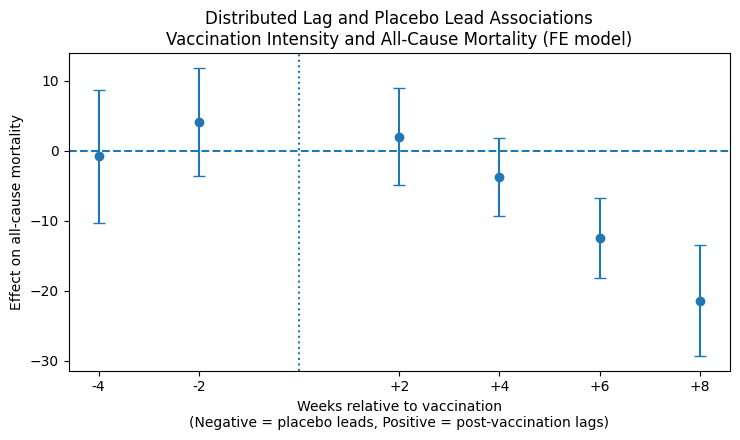

In [9]:
# =========================
# ACM — FE — RAW — full sample (89)
# =========================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

import rpy2.robjects as ro
from rpy2.robjects.conversion import localconverter
from rpy2.robjects import pandas2ri

# -------------------------
# 0. Load fixest (NO installs)
# -------------------------
ro.r(r"""
if (!requireNamespace("fixest", quietly = TRUE)) {
  stop("Package 'fixest' not installed.")
}
suppressMessages(library(fixest))
""")

# -------------------------
# 1. Load data
# -------------------------
df = pd.read_csv(
    r"C:\Maass\cross_national_covid_19_risk_policy_dataset_v1_archived\cross_national_covid_19_risk_policy_dataset_v1.csv",
    parse_dates=["date"]
).sort_values(["country", "date"]).reset_index(drop=True)

# -------------------------
# 2. Time index + centered time
# -------------------------
df["t"] = df.groupby("country").cumcount()
df["t_c"] = df["t"] - df.groupby("country")["t"].transform("mean")

# -------------------------
# 3. Vaccination lags & placebo leads
# -------------------------
LAGS  = [2, 4, 6, 8]
LEADS = [2, 4]

for k in LAGS:
    df[f"vax_lag{k}"] = df.groupby("country")[
        "covid_19_vaccine_doses_administered"
    ].shift(k)

for k in LEADS:
    df[f"vax_lead{k}"] = df.groupby("country")[
        "covid_19_vaccine_doses_administered"
    ].shift(-k)

# Fixed interactions
df["vax_lag6_x_tc"] = df["vax_lag6"] * df["t_c"]
df["vax_lag8_x_tc"] = df["vax_lag8"] * df["t_c"]

# -------------------------
# 4. Drop NA (single analytic sample)
# -------------------------
MODEL_VARS = [
    "all_cause_mortality", "country", "t", "t_c",
    "vax_lead2", "vax_lead4",
    "vax_lag2", "vax_lag4", "vax_lag6", "vax_lag8",
    "vax_lag6_x_tc", "vax_lag8_x_tc",
    "covid_19_incidence_original",
    "covid_19_prevalence_original",
    "covid_19_policy_stringency",
    "covid_19_face_covering_policy",
    "covid_19_testing_tracing_policy",
    "covid_19_variant_delta",
    "covid_19_variant_omicron",
    "sine_seasonality", "cosine_seasonality",
    "temperature", "relative_humidity",
]

df_m = df.dropna(subset=MODEL_VARS).copy()

print("Countries:", df_m["country"].nunique())
print("Rows:", df_m.shape[0])

# -------------------------
# 5. Send to R
# -------------------------
with localconverter(pandas2ri.converter):
    ro.globalenv["df_m"] = df_m

# -------------------------
# 6. FE model in R (fixest::feols) + HAC SE
# -------------------------
ro.r(r"""
df_m$country <- as.factor(df_m$country)

m_core_fe <- feols(
  all_cause_mortality ~
    t_c +
    vax_lead2 + vax_lead4 +
    vax_lag2 + vax_lag4 + vax_lag6 + vax_lag8 +
    vax_lag6_x_tc + vax_lag8_x_tc +
    covid_19_incidence_original +
    covid_19_prevalence_original +
    covid_19_policy_stringency +
    covid_19_face_covering_policy +
    covid_19_testing_tracing_policy +
    covid_19_variant_delta +
    covid_19_variant_omicron +
    sine_seasonality + cosine_seasonality +
    temperature + relative_humidity
  | country,
  data = df_m,
  panel.id = ~country + t
)

# HAC / Newey–West inference (nlag=1)
tt <- as.data.frame(coeftable(m_core_fe, vcov = "NW", nlag = 1))

tt$term <- rownames(tt)
rownames(tt) <- NULL

names(tt) <- sub("^Estimate$", "estimate", names(tt))
names(tt) <- sub("^Std\\. Error$", "se", names(tt))
names(tt) <- sub("^Pr\\(>\\|t\\|\\)$", "p_value", names(tt))

tt
""")

with localconverter(pandas2ri.converter):
    tt = ro.r("tt")

# -------------------------
# 7. Output table (vaccination terms only)
# -------------------------
TERMS = [
    "vax_lead2","vax_lead4",
    "vax_lag2","vax_lag4","vax_lag6","vax_lag8",
    "vax_lag6_x_tc","vax_lag8_x_tc"
]

TERM_NAMES = {
    "vax_lead2": "Vaccination lead (t+2)",
    "vax_lead4": "Vaccination lead (t+4)",
    "vax_lag2":  "Vaccination lag (t−2)",
    "vax_lag4":  "Vaccination lag (t−4)",
    "vax_lag6":  "Vaccination lag (t−6)",
    "vax_lag8":  "Vaccination lag (t−8)",
    "vax_lag6_x_tc": "Lag 6 × calendar time",
    "vax_lag8_x_tc": "Lag 8 × calendar time",
}

tab = tt[tt["term"].isin(TERMS)].copy()
tab["term"] = pd.Categorical(tab["term"], TERMS)
tab = tab.sort_values("term")

tab["Estimate"] = tab["estimate"].map(lambda x: f"{x:+.3f}")
tab["SE"]       = tab["se"].map(lambda x: f"{x:.3f}")
tab["p-value"]  = tab["p_value"].map(lambda x: f"{x:.3f}")
tab["Term"]     = tab["term"].map(TERM_NAMES)

print("\n=== Fixed Effects (country) — Vaccination Intensity and All-Cause Mortality (ACM) — FE — RAW ===")
print(tab[["Term","Estimate","SE","p-value"]].to_string(index=False))

# -------------------------
# 8. Distributed lag plot (FE model)
# -------------------------
term_to_time = {
    "vax_lead4": -4,
    "vax_lead2": -2,
    "vax_lag2":   2,
    "vax_lag4":   4,
    "vax_lag6":   6,
    "vax_lag8":   8,
}

dfp = tt[tt["term"].isin(term_to_time.keys())].copy()
dfp["time"] = dfp["term"].map(term_to_time)
dfp = dfp.sort_values("time")

x  = dfp["time"].to_numpy()
y  = dfp["estimate"].to_numpy()
se = dfp["se"].to_numpy()

plt.figure(figsize=(7.5, 4.5))
plt.errorbar(x, y, yerr=1.96*se, fmt="o", capsize=4)
plt.axhline(0, linestyle="--")
plt.axvline(0, linestyle=":")
plt.xticks(x, [f"{i:+d}" for i in x])
plt.xlabel("Weeks relative to vaccination\n(Negative = placebo leads, Positive = post-vaccination lags)")
plt.ylabel("Effect on all-cause mortality")
plt.title("Distributed Lag and Placebo Lead Associations\nVaccination Intensity and All-Cause Mortality (FE model)")
plt.tight_layout()
plt.show()


Countries: 89
Rows: 14863

=== Fixed Effects (country) — Vaccination Intensity and Non-COVID-19 Mortality (NCM) — FE — RAW ===
                  Term Estimate    SE p-value
Vaccination lead (t+2)   -0.588 1.223   0.631
Vaccination lead (t+4)   -4.480 2.012   0.027
 Vaccination lag (t−2)   -1.647 1.904   0.388
 Vaccination lag (t−4)   +1.594 1.548   0.305
 Vaccination lag (t−6)   -0.868 1.117   0.438
 Vaccination lag (t−8)   -3.308 1.284   0.011
 Lag 6 × calendar time   +0.114 0.054   0.037
 Lag 8 × calendar time   +0.145 0.058   0.014


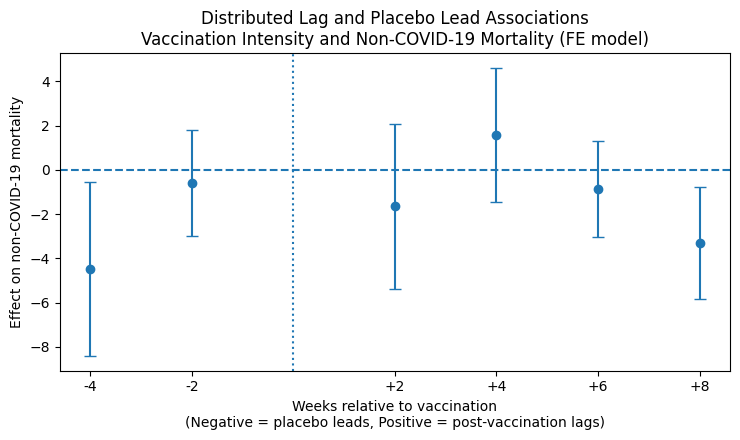

In [10]:
# =========================
# NCM — FE — RAW — full sample (89)
# =========================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

import rpy2.robjects as ro
from rpy2.robjects.conversion import localconverter
from rpy2.robjects import pandas2ri

# -------------------------
# 0. Load fixest (NO installs)
# -------------------------
ro.r(r"""
if (!requireNamespace("fixest", quietly = TRUE)) {
  stop("Package 'fixest' not installed.")
}
suppressMessages(library(fixest))
""")

# -------------------------
# 1. Load data
# -------------------------
df = pd.read_csv(
    r"C:\Maass\cross_national_covid_19_risk_policy_dataset_v1_archived\cross_national_covid_19_risk_policy_dataset_v1.csv",
    parse_dates=["date"]
).sort_values(["country", "date"]).reset_index(drop=True)

# Construct non-COVID mortality (RAW)
df["non_covid_mortality"] = (
    df["all_cause_mortality"] - df["covid_19_mortality_original"]
)

# -------------------------
# 2. Time index + centered time
# -------------------------
df["t"] = df.groupby("country").cumcount()
df["t_c"] = df["t"] - df.groupby("country")["t"].transform("mean")

# -------------------------
# 3. Vaccination lags & placebo leads
# -------------------------
LAGS  = [2, 4, 6, 8]
LEADS = [2, 4]

for k in LAGS:
    df[f"vax_lag{k}"] = df.groupby("country")[
        "covid_19_vaccine_doses_administered"
    ].shift(k)

for k in LEADS:
    df[f"vax_lead{k}"] = df.groupby("country")[
        "covid_19_vaccine_doses_administered"
    ].shift(-k)

# Fixed interactions
df["vax_lag6_x_tc"] = df["vax_lag6"] * df["t_c"]
df["vax_lag8_x_tc"] = df["vax_lag8"] * df["t_c"]

# -------------------------
# 4. Drop NA (single analytic sample)
# -------------------------
MODEL_VARS = [
    "non_covid_mortality", "country", "t", "t_c",
    "vax_lead2", "vax_lead4",
    "vax_lag2", "vax_lag4", "vax_lag6", "vax_lag8",
    "vax_lag6_x_tc", "vax_lag8_x_tc",
    "covid_19_incidence_original",
    "covid_19_prevalence_original",
    "covid_19_policy_stringency",
    "covid_19_face_covering_policy",
    "covid_19_testing_tracing_policy",
    "covid_19_variant_delta",
    "covid_19_variant_omicron",
    "sine_seasonality", "cosine_seasonality",
    "temperature", "relative_humidity",
]

df_m = df.dropna(subset=MODEL_VARS).copy()

print("Countries:", df_m["country"].nunique())
print("Rows:", df_m.shape[0])

# -------------------------
# 5. Send to R
# -------------------------
with localconverter(pandas2ri.converter):
    ro.globalenv["df_m"] = df_m

# -------------------------
# 6. FE model in R (fixest::feols) + HAC SE
# -------------------------
ro.r(r"""
df_m$country <- as.factor(df_m$country)

m_core_fe_ncm <- feols(
  non_covid_mortality ~
    t_c +
    vax_lead2 + vax_lead4 +
    vax_lag2 + vax_lag4 + vax_lag6 + vax_lag8 +
    vax_lag6_x_tc + vax_lag8_x_tc +
    covid_19_incidence_original +
    covid_19_prevalence_original +
    covid_19_policy_stringency +
    covid_19_face_covering_policy +
    covid_19_testing_tracing_policy +
    covid_19_variant_delta +
    covid_19_variant_omicron +
    sine_seasonality + cosine_seasonality +
    temperature + relative_humidity
  | country,
  data = df_m,
  panel.id = ~country + t
)

# HAC / Newey–West inference (nlag=1)
tt <- as.data.frame(coeftable(m_core_fe_ncm, vcov = "NW", nlag = 1))

tt$term <- rownames(tt)
rownames(tt) <- NULL

names(tt) <- sub("^Estimate$", "estimate", names(tt))
names(tt) <- sub("^Std\\. Error$", "se", names(tt))
names(tt) <- sub("^Pr\\(>\\|t\\|\\)$", "p_value", names(tt))

tt
""")

with localconverter(pandas2ri.converter):
    tt = ro.r("tt")

# -------------------------
# 7. Output table (vaccination terms only)
# -------------------------
TERMS = [
    "vax_lead2","vax_lead4",
    "vax_lag2","vax_lag4","vax_lag6","vax_lag8",
    "vax_lag6_x_tc","vax_lag8_x_tc"
]

TERM_NAMES = {
    "vax_lead2": "Vaccination lead (t+2)",
    "vax_lead4": "Vaccination lead (t+4)",
    "vax_lag2":  "Vaccination lag (t−2)",
    "vax_lag4":  "Vaccination lag (t−4)",
    "vax_lag6":  "Vaccination lag (t−6)",
    "vax_lag8":  "Vaccination lag (t−8)",
    "vax_lag6_x_tc": "Lag 6 × calendar time",
    "vax_lag8_x_tc": "Lag 8 × calendar time",
}

tab = tt[tt["term"].isin(TERMS)].copy()
tab["term"] = pd.Categorical(tab["term"], TERMS)
tab = tab.sort_values("term")

tab["Estimate"] = tab["estimate"].map(lambda x: f"{x:+.3f}")
tab["SE"]       = tab["se"].map(lambda x: f"{x:.3f}")
tab["p-value"]  = tab["p_value"].map(lambda x: f"{x:.3f}")
tab["Term"]     = tab["term"].map(TERM_NAMES)

print("\n=== Fixed Effects (country) — Vaccination Intensity and Non-COVID-19 Mortality (NCM) — FE — RAW ===")
print(tab[["Term","Estimate","SE","p-value"]].to_string(index=False))

# -------------------------
# 8. Distributed lag plot (NCM FE model)
# -------------------------
term_to_time = {
    "vax_lead4": -4,
    "vax_lead2": -2,
    "vax_lag2":   2,
    "vax_lag4":   4,
    "vax_lag6":   6,
    "vax_lag8":   8,
}

dfp = tt[tt["term"].isin(term_to_time.keys())].copy()
dfp["time"] = dfp["term"].map(term_to_time)
dfp = dfp.sort_values("time")

x  = dfp["time"].to_numpy()
y  = dfp["estimate"].to_numpy()
se = dfp["se"].to_numpy()

plt.figure(figsize=(7.5, 4.5))
plt.errorbar(x, y, yerr=1.96*se, fmt="o", capsize=4)
plt.axhline(0, linestyle="--")
plt.axvline(0, linestyle=":")
plt.xticks(x, [f"{i:+d}" for i in x])
plt.xlabel("Weeks relative to vaccination\n(Negative = placebo leads, Positive = post-vaccination lags)")
plt.ylabel("Effect on non-COVID-19 mortality")
plt.title(
    "Distributed Lag and Placebo Lead Associations\n"
    "Vaccination Intensity and Non-COVID-19 Mortality (FE model)"
)
plt.tight_layout()
plt.show()
